In [1]:
%load_ext autoreload
%autoreload 2

****************************************
# Galactic: Crab Analysis (DC1 and DC2)

This notebook analyzes the Crab source using both the **DC1-style Crab simulation** and the newer **DC2 Crab simulation**.

The purpose is to compare the two analysis cases within the DC2 framework while reusing a familiar source.

For **Crab DC1**, the goals are to:

- Localize the source
- Measure the spectrum
- Reconstruct an image of the source

For **Crab DC2**, the goal is to:

- Detect the source
- Measure the phase-integrated spectrum

The DC2 Crab simulation includes the combined **pulsar + nebula spectrum**, divided into five energy bands from **100 keV to 10 MeV**. 
**************

## set up

### imports

In [50]:
from pathlib import Path
import sys
repo_root = Path.cwd().parent

# Gerneral imports
import numpy as np
import matplotlib.pyplot as plt

# COSI imports
import cosipy as cp 
from cosipy.statistics import PoissonLikelihood
from cosipy.interfaces import ThreeMLPluginInterface

# craft information imports
from scoords import SpacecraftFrame

# others
import astropy.units as u
from astropy.coordinates import SkyCoord

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from astropy.io import fits

%matplotlib inline

### data

Define file names

In [3]:
data_dir = Path(repo_root, "data")

data_crab_dc1 = data_dir / "data-products/downloads/crab_3months_unbinned_data.fits.gz"
data_crab_dc2 = data_dir / "data-products/downloads/Crab_DC2_3months_unbinned_data.fits.gz"
data_orientation = data_dir / "data-products" / "downloads" / "20280301_3_month_with_orbital_info.fits"


data_response = data_dir / (
    "data-products/downloads/"
    "SMEXv12.Continuum.HEALPixO3_10bins_log_flat."
    "binnedimaging.imagingresponse.h5"
)

data_background = data_dir / "backgrounds/downloads/total_bg_3months_unbinned_data.fits.gz"

In [4]:
# Paths to the binned data files
crab_dc1_binned = repo_root / "data" / "data-products" / "binned" / "crab_binned_data_dc1.hdf5"
crab_dc2_binned = repo_root / "data" / "data-products" / "binned" / "crab_binned_data_dc2.hdf5"
background_binned = repo_root / "data" / "backgrounds" / "binned" / "background_binned_data.hdf5"

In [5]:

# Checking the contents of the FITS file for YAML file creation
with fits.open(data_crab_dc1) as hdul:
    hdul.info()
    print(hdul[1].columns.names)
    # Checking the time range of the data
    times = hdul[1].data["TimeTags"]
# Obtaining the minimum and maximum time values from the TimeTags column
print('tmin:', times.min(), 'tmax:', times.max())

Filename: /Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/crab_3months_unbinned_data.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     46   6432442R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']
tmin: 1835487684.5801868 tmax: 1843466661.583874


### Inputs

In [55]:
l_crab,b_crab = 184.55746, -5.78436 # Galactic longitude & latitude of Crab in degrees

# Initial spectral parameters from the Crab fitting tutorial.
alpha = -1.99
beta = -2.32
E0 = 531.0 * (alpha - beta) * u.keV
xp = E0 * (alpha + 2) / (alpha - beta)
piv = 500.0 * u.keV
K = 3.07e-5 / u.cm**2 / u.s / u.keV

***
## Binning the Data

### DC1, DC2 & background binning

In [7]:
# In this part, it seems that it read the intups.yaml (this is the file that contains the inputs for the analysis.)
# In data-challenge-1 this was done in the notebook, but in data-challenge-2 it is done in the inputs.yaml file. (automated)
analysis1 = cp.BinnedData("inputs.yaml")
analysis2 = cp.BinnedData("inputs.yaml")
analysisbg = cp.BinnedData("inputs.yaml")



In [8]:
# Create the bins if the binned data files do not exist yet

if not crab_dc1_binned.exists():
    analysis1.get_binned_data(
        unbinned_data=str(data_crab_dc1),
        output_name=str(crab_dc1_binned.with_suffix(""))
    )

if not crab_dc2_binned.exists():
    analysis2.get_binned_data(
        unbinned_data=str(data_crab_dc2),
        output_name=str(crab_dc2_binned.with_suffix(""))
    )

if not background_binned.exists():
    analysisbg.get_binned_data(
        unbinned_data=str(data_background),
        output_name=str(background_binned.with_suffix(""))
    )

# Always load the existing/generated files into the objects
analysis1.load_binned_data_from_hdf5(
    binned_data=str(crab_dc1_binned)
)
analysis2.load_binned_data_from_hdf5(
    binned_data=str(crab_dc2_binned)
)
analysisbg.load_binned_data_from_hdf5(
    binned_data=str(background_binned)
)

In [9]:
# Since we loaded the binned data from the HDF5 files, we can now get the binning information for each analysis object
analysis1.get_binning_info()
analysis2.get_binning_info()
analysisbg.get_binning_info()

In [10]:
# are our data files created?
print("Crab DC1 binned data exists:", crab_dc1_binned.exists())
print("Crab DC2 binned data exists:", crab_dc2_binned.exists()) 
print("Background binned data exists:", background_binned.exists())

Crab DC1 binned data exists: True
Crab DC2 binned data exists: True
Background binned data exists: True


### Exploring raw binned data: File shape & plots

In [11]:
# lets see the shape of the binned data
print("Crab DC1 binned data shape:", analysis1.binned_data.shape)
print("Crab DC2 binned data shape:", analysis2.binned_data.shape)
print("Background binned data shape:", analysisbg.binned_data.shape) 

Crab DC1 binned data shape: (1108, 10, 36, 768)
Crab DC2 binned data shape: (1108, 10, 36, 768)
Background binned data shape: (1108, 10, 36, 768)


In [12]:
# Inspect the bin centers, edges, and widths for time and energy
print("Time centers:", analysis1.time_bin_centers)
print("Time widths:", analysis1.time_bin_widths)

print("Energy centers:", analysis1.energy_bin_centers)
print("Energy edges:", analysis1.energy_bin_edges)
print("Energy widths:", analysis1.energy_bin_widths)

Time centers: [1.83549129e+09 1.83549849e+09 1.83550569e+09 ... 1.84344866e+09
 1.84345586e+09 1.84346306e+09] s
Time widths: [7201.24278307 7201.24278307 7201.24278331 ... 7201.24278331 7201.24278307
 7201.24278307] s
Energy centers: [ 129.2445  204.839   324.648   514.532   815.4785 1292.445  2048.39
 3246.48   5145.32   8154.785 ] keV
Energy edges: [  100.      158.489   251.189   398.107   630.957  1000.     1584.89
  2511.89   3981.07   6309.57  10000.   ] keV
Energy widths: [  58.489   92.7    146.918  232.85   369.043  584.89   927.    1469.18
 2328.5   3690.43 ] keV


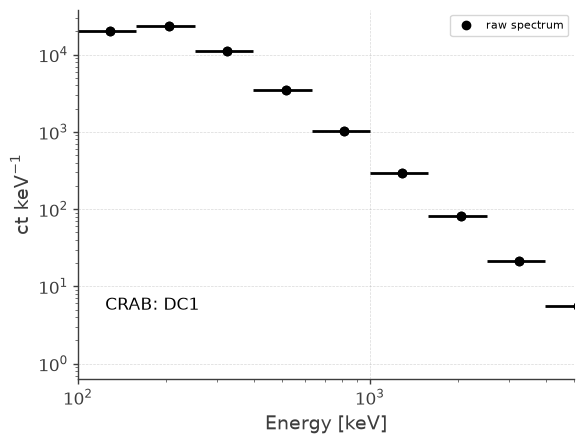

In [13]:
# Plot the raw spectrum for DC1
# We first add text in the plot indicating "Crab: DC1"
fig, ax = plt.subplots()
ax.text(0.15, 0.2, 'CRAB: DC1', transform=ax.transAxes, ha='center', va='center')
analysis1.get_raw_spectrum(show_plots=True
)


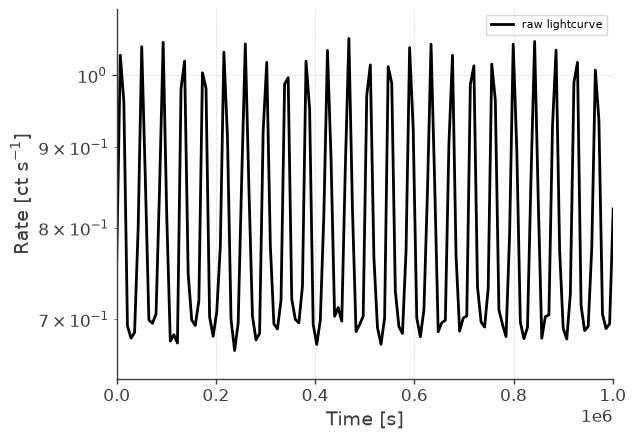

In [14]:
# Plotting DC1 lightcurve
plt.figure()
plt.xlim(0, 1e6)
analysis1.get_raw_lightcurve(show_plots=True)

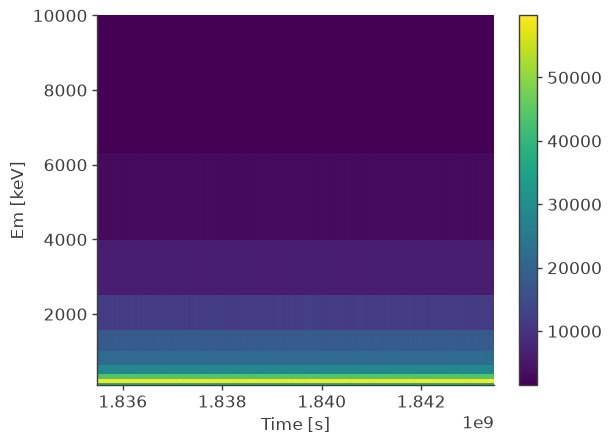

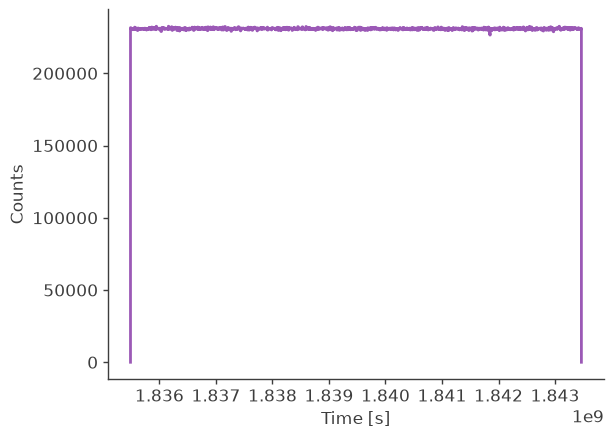

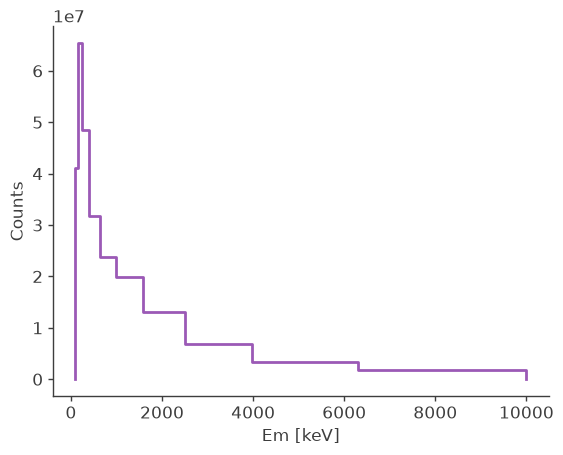

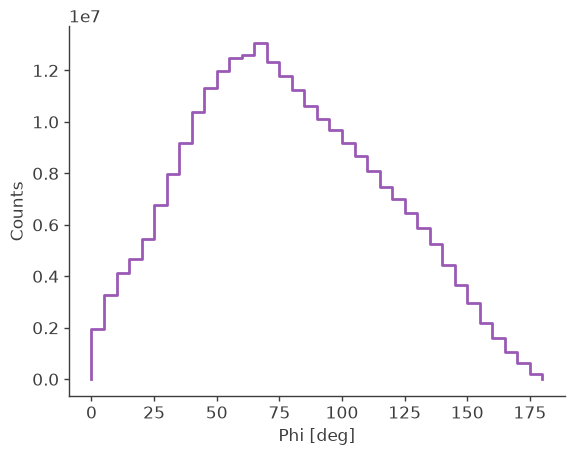

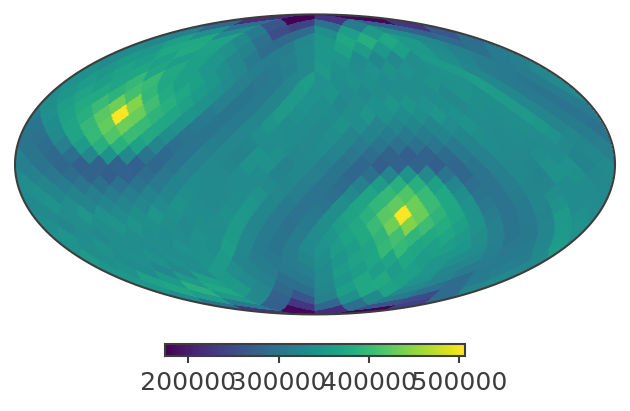

In [15]:
# Plot the binned data projected onto each axis
analysisbg.plot_binned_data(show_plots=True)

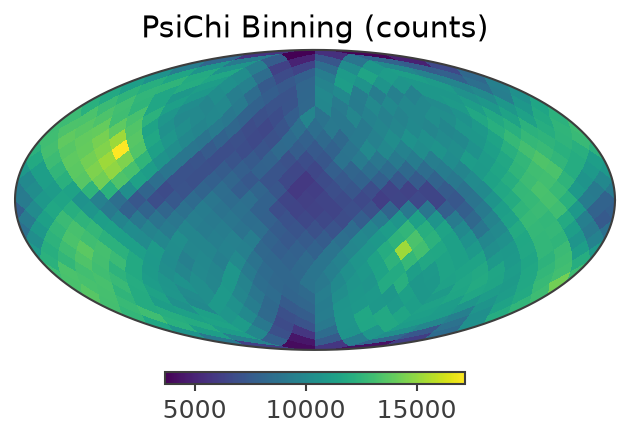

In [16]:
# Plot the event distribution in PsiChi coordinates
analysis2.plot_psichi_map(show_plots=True)

*******
## Detector response & signal expectation

###  Detector response

In [17]:
# Open and inspect the detector response
# Combine the detector response with the Crab exposure to build its observation-specific response.
# The PSR describes how photons from the Crab would be recorded by COSI.
with cp.response.FullDetectorResponse.open(data_response) as response:
    print("Response axes:", response.axes.labels)
    print('----------------------------------------------------------------')
    print('------------------------- Description --------------------------')
    print('----------------------------------------------------------------')
    print(repr(response))
    print('----------------------------------------------------------------')
    print('')
    print(f"NSIDE = {response.nside}")
    print(f"SCHEME = {response.scheme}")
    print(f"NPIX = {response.npix}")
    print(f"Pixel size = {np.sqrt(response.pixarea()).to(u.deg):.2f}")
    print('')
    print('----------------------------------------------------------------')
    

Response axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
----------------------------------------------------------------
------------------------- Description --------------------------
----------------------------------------------------------------
FILENAME: '/Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1

In [18]:
# Inspect the detector response for one fixed direction in the COSI frame.
# A sky-fixed source moves in this frame as COSI rotates, so its final
# point-source response must include the spacecraft attitude history.
with cp.response.FullDetectorResponse.open(data_response) as response:

    drm = response.get_interp_response(SkyCoord(lon = 0*u.deg, lat = 90*u.deg, frame = SpacecraftFrame()))

(<Axes: xlabel='Ei [keV]', ylabel='Em [keV]'>,
 <matplotlib.collections.QuadMesh at 0x1297796d0>)

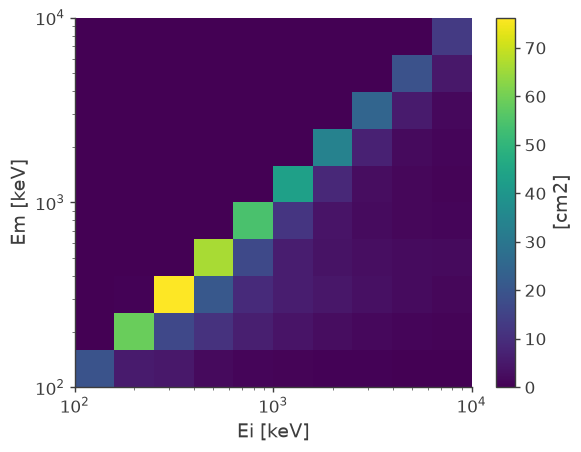

In [19]:
# effective area and the energy dispersion matrix. 
# The effective area can also be evaluated at a specific energy of interest:
# e.g.  drm.get_effective_area(energy_of_interest)
drm.get_spectral_response().plot()

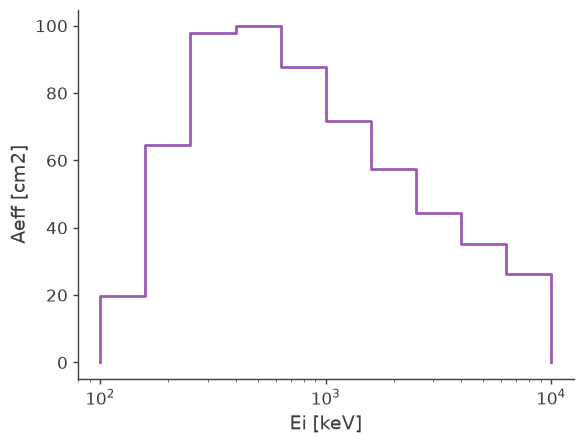

In [20]:
# The effective area can also be evaluated at a specific energy of interest:
# drm.get_effective_area(energy_of_interest)
ax,plot = drm.get_effective_area().plot();

ax.set_ylabel(f'Aeff [{drm.unit}]');

### Point source response

In [21]:
# Load the space craft orientation history
orientation = cp.SpacecraftHistory.open(data_orientation)

# Define the target coordinates (Crab)
target_coord = SkyCoord(l_crab, b_crab, unit = 'deg', frame = "galactic")

#-----------------------------------------------------------------------------------
# Build a dwell-time map for the Crab using COSI's orientation history.          
# It records how long the Crab was observed from each direction relative to COSI,
# so the detector response can later be averaged over the full observation.
#-----------------------------------------------------------------------------------
with cp.response.FullDetectorResponse.open(data_response) as response:
    dwell_time_map = orientation.get_dwell_map(target_coord = target_coord, base = response)

In [22]:
with cp.response.FullDetectorResponse.open(data_response) as response:
    psr = response.get_point_source_response(
        exposure_map=dwell_time_map,
        coord=target_coord
    )

In [23]:
# Define a trial Crab spectrum: F(E) = K * (E / piv)**index.
# These parameters are an initial hypothesis, not values measured from the data.

index = -1
K = 10**-3 / u.cm / u.cm / u.s / u.keV
piv = 100 * u.keV

spectrum = Powerlaw()
spectrum.index.value = index
spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

# Fold the trial spectrum through the PSR to predict the counts COSI would measure.
expectation = psr.get_expectation(spectrum)

Text(0, 0.5, 'Expected counts')

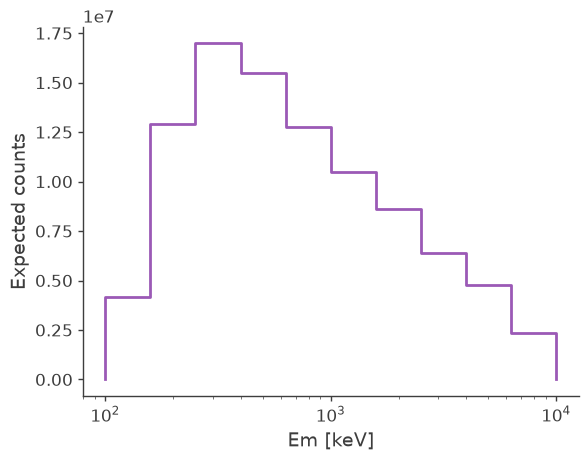

In [24]:
# Project the prediction onto measured energy (Em); this is not the observed spectrum yet.
ax, plot = expectation.project('Em').plot()

ax.set_ylabel('Expected counts')

### Point source response in inertial coordinates

Here, we include COSI's changing orientation to build the Crab response in Galactic coordinates.

In [25]:
# Track how long COSI spent in each orientation during the observation.
# This allows the detector response to be rotated into inertial coordinates.
scatt_map = orientation.get_scatt_map(nside = 16, earth_occ = False)


In [26]:
# Build the Crab response in Galactic coordinates using the spacecraft attitude history.
coord = SkyCoord.from_name('Crab').galactic

with cp.response.FullDetectorResponse.open(data_response) as response:
    psr = response.get_point_source_response(coord = coord, scatt_map = scatt_map)

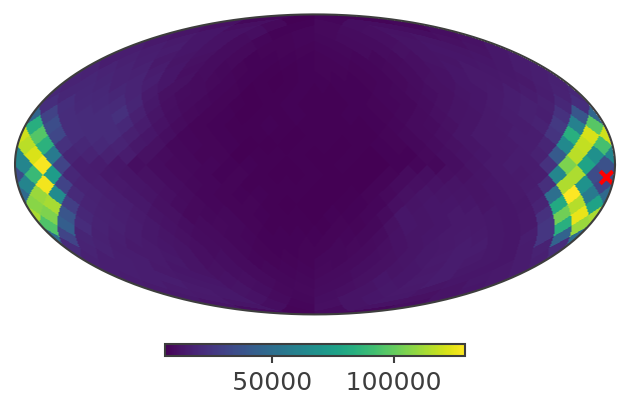

In [27]:
# Select one energy and Compton-angle bin, then project the PSR onto the sky.
# The red marker shows the known Galactic position of the Crab.
psichi_slice = psr.slice[{'Ei':4, 'Phi':4}].project('PsiChi')

ax,plot = psichi_slice.plot(ax_kw = {'coord':'G'})

ax.scatter([coord.l.deg], [coord.b.deg], transform = ax.get_transform('world'), marker = 'x', color = 'red')


Text(0, 0.5, 'Expected counts')

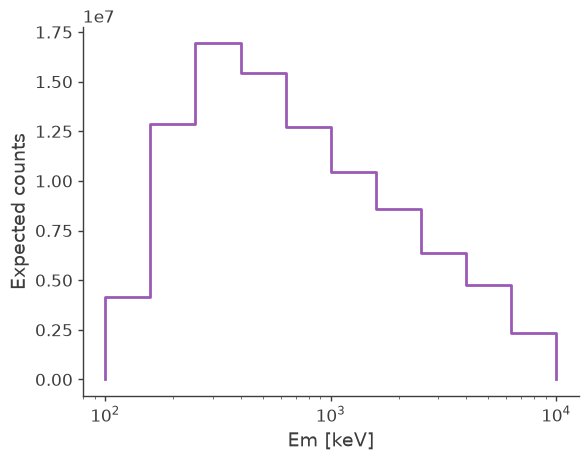

In [28]:
expectation = psr.get_expectation(spectrum)

ax, plot = expectation.project('Em').plot()

ax.set_ylabel('Expected counts')

*****
## Fitting the Spectrum

In [33]:
# Integrate both DC1 & DC2 and the backgroiund over time
dc1_source_counts = analysis1.binned_data.project("Em", "Phi", "PsiChi")
dc2_source_counts = analysis2.binned_data.project("Em", "Phi", "PsiChi")
bg_source_counts = analysisbg.binned_data.project("Em", "Phi", "PsiChi")

In [47]:
# Create the two similated observations (appropiate data interface)
data_dc1 = cp.data_io.EmCDSBinnedData(dc1_source_counts + bg_source_counts)
data_dc2 = cp.data_io.EmCDSBinnedData(dc2_source_counts + bg_source_counts)

In [38]:

# Keep the background shape separate for both fits.
background_distribution = {
    "total_background": bg_source_counts
}


# Create an adjustable background model while keeping its distribution fixed.
# During the fit, only the total background normalization can change.
background_model = cp.background_estimation.FreeNormBinnedBackground(
    background_distribution,
    sc_history=orientation,
    copy=False
)

*****
**Detector response**

The detector response is connected to the binning of each dataset. During the fit,
3ML will use it repeatedly to predict the counts for different source parameters
and find the model that best reproduces the observations.
****

In [40]:
# Adapt the physical detector response to the binning of each dataset.
# These objects describe how COSI records photons, before applying a spectral model.
detector_response = cp.response.FullDetectorResponse.open(data_response)

instrument_response_dc1 = cp.response.BinnedInstrumentResponse(
    detector_response,
    data_dc1
)

instrument_response_dc2 = cp.response.BinnedInstrumentResponse(
    detector_response,
    data_dc2
)

In [41]:
# Create the 3ML point-source response for DC1.
psr_dc1 = cp.response.BinnedThreeMLPointSourceResponse(
    data=data_dc1,
    instrument_response=instrument_response_dc1,
    sc_history=orientation,
    energy_axis=detector_response.axes["Ei"],
    polarization_axis=(
        detector_response.axes["Pol"]
        if "Pol" in detector_response.axes.labels
        else None
    ),
    nside=2 * data_dc1.axes["PsiChi"].nside
)

In [42]:
# Create the 3ML point-source response for DC2.
psr_dc2 = cp.response.BinnedThreeMLPointSourceResponse(
    data=data_dc2,
    instrument_response=instrument_response_dc2,
    sc_history=orientation,
    energy_axis=detector_response.axes["Ei"],
    polarization_axis=(
        detector_response.axes["Pol"]
        if "Pol" in detector_response.axes.labels
        else None
    ),
    nside=2 * data_dc2.axes["PsiChi"].nside
)

In [44]:
# Connect each PSR to the spectral models tested by 3ML during the fit.
# These objects convert every trial spectrum into expected counts in the data bins.
response_dc1 = cp.response.BinnedThreeMLModelFolding(data = data_dc1, point_source_response = psr_dc1 )
response_dc2 = cp.response.BinnedThreeMLModelFolding(data = data_dc2, point_source_response = psr_dc2 )

In [ ]:
# Lokelihood 
like_dc1_fun = PoissonLikelihood(data_dc1, response_dc1,background_model)
like_dc2_fun = PoissonLikelihood(data_dc2, response_dc2,background_model)


In [51]:
# Init 3ML plugin for dc1 and dc2
cosi_dc1 = ThreeMLPluginInterface('cosi_dc1',
                              like_dc1_fun,
                              response_dc1,
                              background_model)

cosi_dc2 = ThreeMLPluginInterface('cosi_dc2',
                              like_dc2_fun,
                              response_dc2,
                              background_model)

In [54]:
# Allow the total background normalization to vary independently in each fit.
for background_label in background_distribution:
    cosi_dc1.bkg_parameter[background_label] = Parameter(
        background_label,
        1,
        min_value=0,
        max_value=100,
        delta=0.05,
        unit=u.Hz
    )

    cosi_dc2.bkg_parameter[background_label] = Parameter(
        background_label,
        1,
        min_value=0,
        max_value=100,
        delta=0.05,
        unit=u.Hz
    )

### Crab source models